## 1. Import Data and EDA

Descriptions of the columns are available [here](./Data/floods_description.md)

In [2]:
import geopandas as gpd

df = gpd.read_file('./Data/floods.gpkg')

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4..."
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0..."
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0..."
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0...."
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0..."


In [3]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   object  
 1   subcounty            1450 non-null   object  
 2   county               1450 non-null   object  
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
dtypes: float64(8), geometry(1), int64(1), object(3)
memory usage: 147.4+ KB


In [4]:
df.duplicated().sum()

0

## 2. Create features and target

I will engineer a new feature: `elevation_range_m`, that is the difference between the maximum (`elevation_max_m`) and minimum (`elevation_min_m`) elevations. Thi is important because places with steeper slopes i.e. greater elevation ranges tend to flood less compared to flat areas with lower eleation ranges.

In [5]:
df['elevation_range_m'] = df['elevation_max_m'] - df['elevation_min_m']

df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry,elevation_range_m
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4...",151.0
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0...",158.0
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0...",147.0
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0....",275.0
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0...",330.0


In [6]:
df.columns

Index(['ward', 'subcounty', 'county', 'pop2009', 'flooded',
       'rain_cumulative_mm', 'rain_max_daily_mm', 'rain_preflood_7d_mm',
       'elevation_mean_m', 'elevation_min_m', 'elevation_max_m',
       'slope_mean_deg', 'geometry', 'elevation_range_m'],
      dtype='object')

In [7]:
# Drop geometry and metadata columns
feature_columns = [
    'pop2009',
    'rain_cumulative_mm',
    'rain_max_daily_mm',
    'rain_preflood_7d_mm',
    'elevation_mean_m',
    'elevation_min_m',
    'elevation_max_m',
    'elevation_range_m',
    'slope_mean_deg'
]

target_column = 'flooded'

# Features
X = df[feature_columns]
y = df[target_column]

X.head()

,pop2009,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,elevation_range_m,slope_mean_deg
0,17431.0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,151.0,1.413028
1,18755.0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,158.0,2.246821
2,27756.0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,147.0,3.392240
3,27179.0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,275.0,4.263301
4,22874.0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,330.0,3.834336


## 3. Preprocessing

First perform standard **train-test split**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, stratify=y, test_size=0.3)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1015 entries, 454 to 845
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pop2009              1015 non-null   float64
 1   rain_cumulative_mm   1015 non-null   float64
 2   rain_max_daily_mm    1015 non-null   float64
 3   rain_preflood_7d_mm  1015 non-null   float64
 4   elevation_mean_m     1015 non-null   float64
 5   elevation_min_m      1015 non-null   float64
 6   elevation_max_m      1015 non-null   float64
 7   elevation_range_m    1015 non-null   float64
 8   slope_mean_deg       1015 non-null   float64
dtypes: float64(9)
memory usage: 79.3 KB


For neural networks, standardization of the features and targets has to be done.

`y` is a binary column. Thus, it does not need to be standardized

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(1015, 9)

Due to the limited size of the dataset, we will not have validation data.

## 4. Modelling

I will use Keras' API to build the ANN.

I will ensure I use a balanced class weight to account for class imbalance

I will experiment with three types of regularization to see which results in the best metrics:
 - l1 regularization
 - l2 regularization
 - dropout regularization

I will also build a model that implements **Early Stopping**

I will start by building a baseline model that has no regularization whatsoever

In [10]:
# Computing class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_dict = dict(enumerate(class_weights))

class_dict

{0: 0.6342957130358705, 1: 2.3615635179153096}

In [11]:
# Baseline model
import keras
from keras import models, layers

# Instantiate
baseline_model = models.Sequential()
input_shape = (X_train_scaled.shape[1],)

# Add input layer
baseline_model.add(layers.Input(input_shape))

# Add hidden layers
baseline_model.add(layers.Dense(50, activation='relu'))
baseline_model.add(layers.Dense(25, activation='relu'))

# Add output layer
baseline_model.add(layers.Dense(1, activation='sigmoid'))

# Define a helper function to compile and fit the model and return history
def compile_and_fit(model, X_train=X_train_scaled, y_train=y_train, class_dict=class_dict):
    # Compile
    model.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        # I will track recall, auc, f1-score and accuracy
        metrics=[
            'accuracy',
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.F1Score(threshold=0.5, average='micro')
        ]
    )

    # Fit the model
    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=200,
        class_weight=class_dict
    )

    return history

baseline_history = compile_and_fit(baseline_model)

W0000 00:00:1778509055.322231    6808 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778509058.509378    6554 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5320 - auc: 0.3413 - f1_score: 0.0557 - loss: 0.7361 - recall: 0.0651
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5714 - auc: 0.4126 - f1_score: 0.1808 - loss: 0.7222 - recall: 0.2233
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5852 - auc: 0.4710 - f1_score: 0.2653 - loss: 0.7109 - recall: 0.3535
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6099 - auc: 0.5214 - f1_score: 0.3053 - loss: 0.6998 - recall: 0.4047
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6118 - auc: 0.5598 - f1_score: 0.3345 - loss: 0.6908 - recall: 0.4605
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6315 - auc: 0.5959 - f1_score: 0.3704 - loss: 0.6815 - recall: 0.5116
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6443 - auc: 0.6251 - f1_score: 0.3933 - loss: 0.6729 - recall: 0.5442
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 

In [12]:
print(baseline_history.history.keys())

dict_keys(['accuracy', 'auc', 'f1_score', 'loss', 'recall'])


Let's visualize the performance of the model per epoch

In [13]:
# Helper function to visualize metrics
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_metrics(history):
    metrics = list(history.history.keys())
    colors = sns.color_palette('bright', len(metrics))

    fig, axs = plt.subplots(len(metrics), figsize=(15, 10))

    for i, metric in enumerate(metrics):
        ax = axs.flatten()[i]

        ax.set_title(f"{metric.title()} per epoch")
        ax.set_xlabel('Epoch')
        ax.set_ylabel(f'{metric.title()}')

        ax.plot(range(1, len(history.history[metric]) + 1), history.history[metric], color=colors[i], lw=2)
    
    fig.suptitle("Metrics per Epoch")
    plt.show()

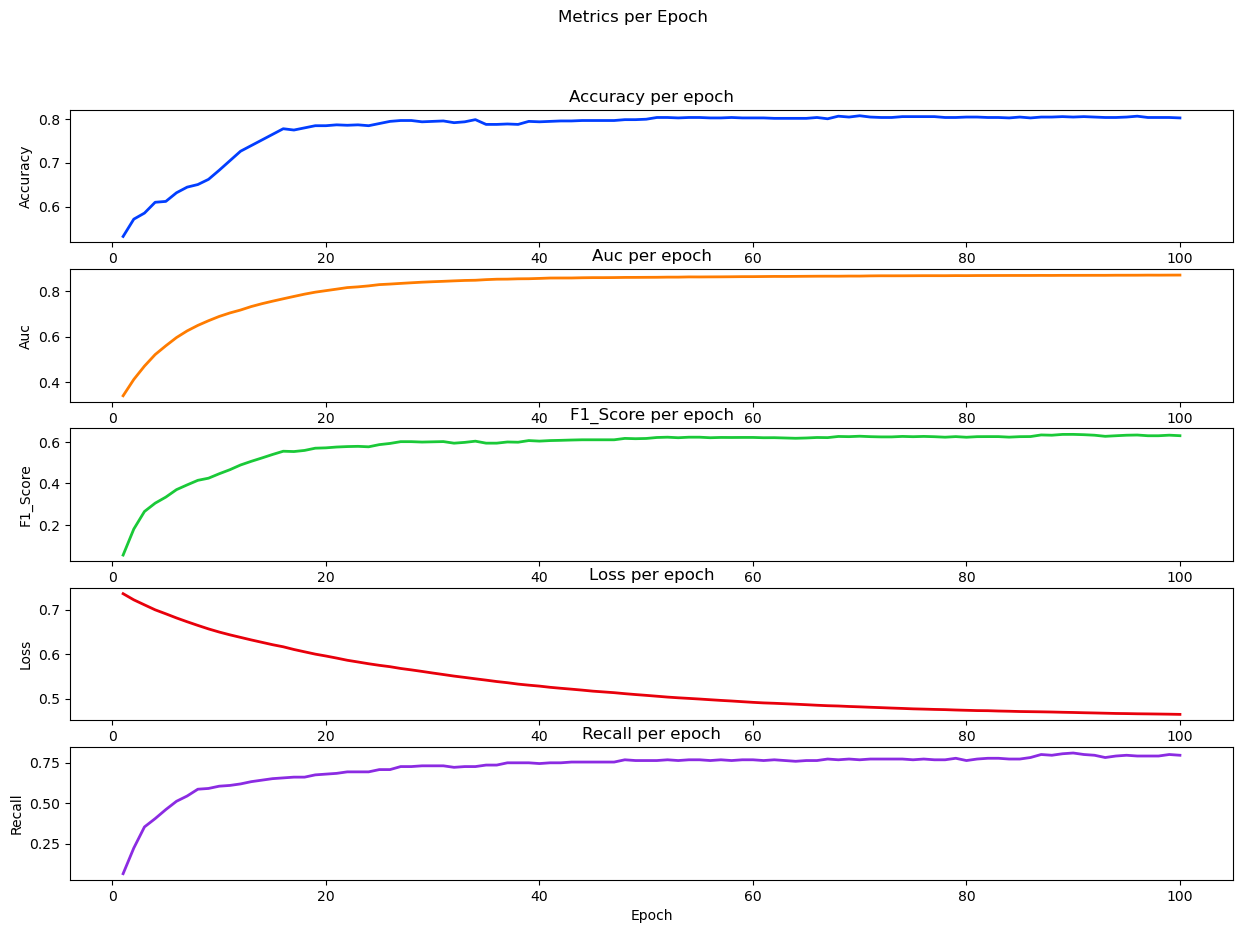

In [14]:
visualize_metrics(baseline_history)

The metrics improve over time as expected

I will now evaluate the model on the train and test set:

In [39]:
# Define a helper function to evaluate a model
def evaluate_model_on_test_and_train(model, X_train=X_train_scaled, y_train=y_train, X_test=X_test_scaled, y_test=y_test):
    print("Train:\n", model.evaluate(X_train, y_train, return_dict=True, verbose=False))
    print("Test:\n", model.evaluate(X_test, y_test, return_dict=True, verbose=False))
    return

evaluate_model_on_test_and_train(baseline_model)

Train:
 {'accuracy': 0.8049260973930359, 'auc': 0.8692994117736816, 'f1_score': 0.631970226764679, 'loss': 0.4723288416862488, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7793103456497192, 'auc': 0.8214761018753052, 'f1_score': 0.58620685338974, 'loss': 0.5345130562782288, 'recall': 0.739130437374115}


Decent performance. I will now apply regularization to see if it improves performance

### a) l1 regularization

I will use an $ \alpha $ of 0.005

In [34]:
l1_model = models.Sequential()

# Add input layer
l1_model.add(layers.Input(input_shape))

# Add hidden layers with l1 regularization applied
l1_model.add(layers.Dense(50, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))
l1_model.add(layers.Dense(25, activation='relu', kernel_regularizer=keras.regularizers.l1(0.005)))

# Add output layer
l1_model.add(layers.Dense(1, activation='sigmoid'))

# Train the model
l1_history = compile_and_fit(l1_model)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2483 - auc: 0.3388 - f1_score: 0.2942 - loss: 2.0094 - recall: 0.7395
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2542 - auc: 0.3807 - f1_score: 0.2997 - loss: 1.9881 - recall: 0.7535
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2631 - auc: 0.4185 - f1_score: 0.3112 - loss: 1.9706 - recall: 0.7860
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2739 - auc: 0.4533 - f1_score: 0.3131 - loss: 1.9535 - recall: 0.7814
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2768 - auc: 0.4903 - f1_score: 0.3140 - loss: 1.9381 - recall: 0.7814
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2768 - auc: 0.5297 - f1_score: 0.3166 - loss: 1.9221 - recall: 0.7907
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2877 - auc: 0.5544 - f1_score: 0.3186 - loss: 1.9096 - recall: 0.7860
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 

Visualizing metric performance:

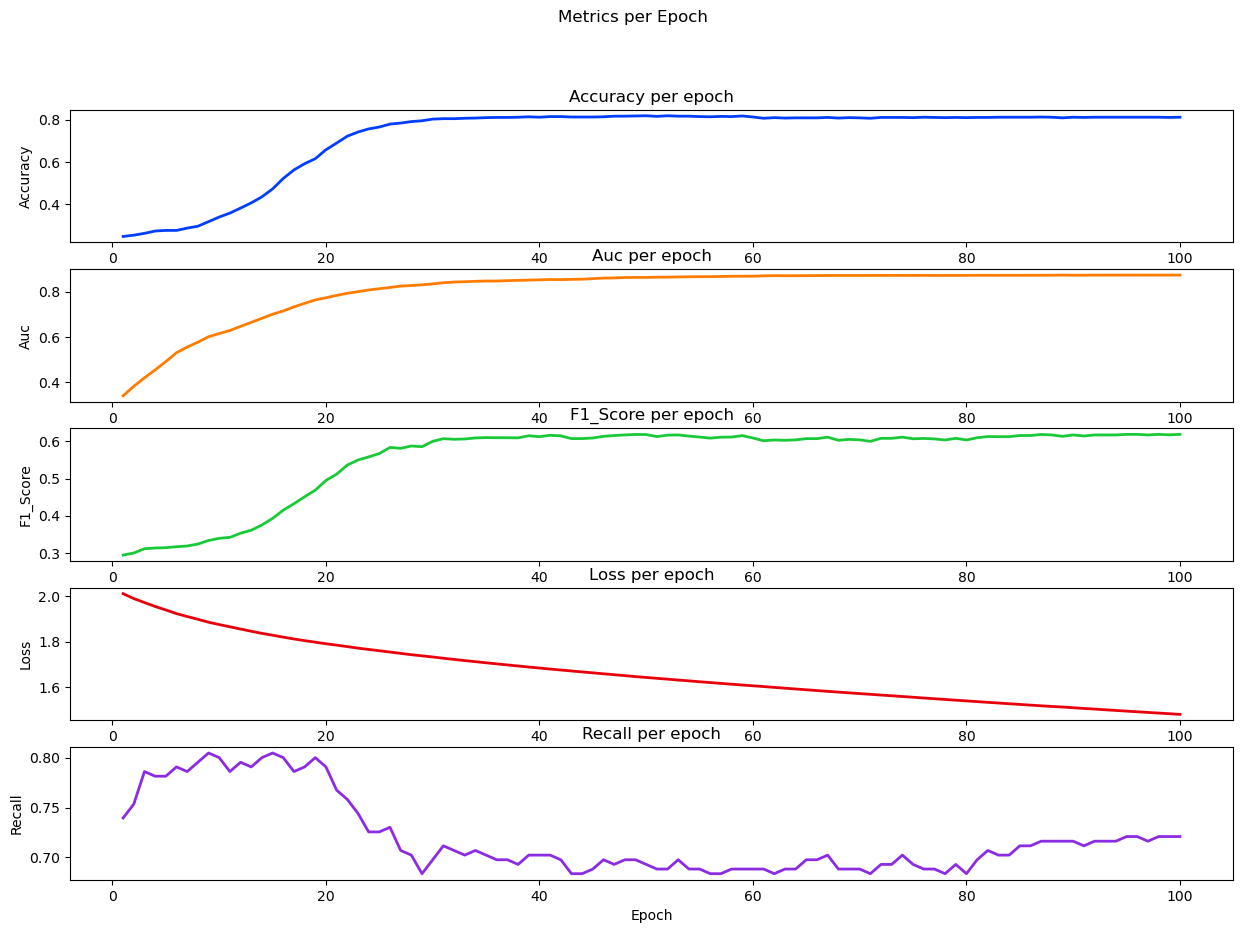

In [35]:
visualize_metrics(l1_history)

The recall appears to be fluctuating.

Evaluating on train and test set:

In [41]:
print("Baseline:")
evaluate_model_on_test_and_train(baseline_model)
print("\n\n")
print("l1 model:")
evaluate_model_on_test_and_train(l1_model)

Baseline:
Train:
 {'accuracy': 0.8049260973930359, 'auc': 0.8692994117736816, 'f1_score': 0.631970226764679, 'loss': 0.4723288416862488, 'recall': 0.7906976938247681}
Test:
 {'accuracy': 0.7793103456497192, 'auc': 0.8214761018753052, 'f1_score': 0.58620685338974, 'loss': 0.5345130562782288, 'recall': 0.739130437374115}



l1 model:
Train:
 {'accuracy': 0.81083744764328, 'auc': 0.8737877607345581, 'f1_score': 0.6144577860832214, 'loss': 1.4945523738861084, 'recall': 0.7116279006004333}
Test:
 {'accuracy': 0.7701149582862854, 'auc': 0.8241856098175049, 'f1_score': 0.5454544425010681, 'loss': 1.552311897277832, 'recall': 0.6521739363670349}


The l1 model appears to have comparable performance to the baseline (except for probably a much lower recall score)

### b) l2 regularization